# Debug difficult samples for classification

In [17]:
import torch
import sys
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO, event_representations
from topspin_datamodule import TopspinDataModule, pad_collate_fn
from topspin_classification_module import TopspinLitModule
from TOPSPIN import Hdf5Dataset
from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import os

## Load checkpoints

In [11]:
# finetuned 6 class model
checkpoint_path = "../logs/train/runs/" + "2025-10-09_18-01-46/" + "checkpoints/" + "epoch_159.ckpt"

# tmp while training
checkpoint_path = "/home/lkolmar/Desktop/epoch_083.ckpt"


model = TopspinLitModule.load_from_checkpoint(checkpoint_path)

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [12]:
print(model)

TopspinLitModule(
  (net): FireNet(
    (conv): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (res1): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
    )
    (res2): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
    )
    (convgru1): ConvGRU(
      (update_gate): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (reset_gate): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (out_gate): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (convgru2): ConvGRU(
      (update_gate): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (reset_gate): Conv2d(32, 16, kernel_size=(3, 3),

In [13]:
# Just to have the module
data_module = TopspinDataModule(
    data_dir="/data/lkolmar/datasets/topspin_fit_to_max/",
    time_window=7000,  # in us
    num_bins=10,
    sensor_size=(100, 100),
    train_val_test_split=(1294, 277, 277),  # n = 1848 (70%, 15%, 15%)
    batch_size=8,
    num_workers=4,
    pin_memory=True,
)
data_module.prepare_data()
data_module.setup()

Flipped: False

------------------------------------------------------------------------

Train indices: [1590, 1, 1334, 52, 954, 1596, 298, 1188, 78, 440, 1790, 1297, 722, 952, 771, 895, 1347, 1761, 1515, 530, 377, 119, 603, 1434, 323, 1001, 221, 1440, 1255, 1247, 636, 600, 443, 1177, 211, 1792, 755, 1579, 1070, 870, 1810, 800, 985, 362, 1199, 353, 383, 1236, 741, 1041, 1492, 1527, 626, 1647, 1624, 1027, 1399, 665, 376, 421, 1370, 1796, 1652, 313, 510, 427, 171, 1703, 799, 1513, 963, 1226, 1648, 1051, 842, 1805, 1107, 1038, 986, 470, 174, 775, 1408, 426, 1474, 1340, 283, 123, 1083, 1169, 511, 2, 509, 567, 1839, 1830, 625, 944, 459, 308, 554, 1127, 453, 1023, 105, 1812, 1651, 95, 1093, 357, 319, 102, 1343, 1459, 1016, 1189, 840, 1231, 289, 493, 1223, 23, 441, 1769, 916, 80, 1503, 846, 587, 551, 1655, 1101, 980, 1458, 74, 433, 776, 1235, 138, 1714, 979, 1542, 1523, 417, 1207, 700, 1312, 695, 1316, 1184, 1012, 540, 1336, 871, 1478, 642, 546, 431, 1348, 1747, 1206, 731, 937, 1355, 1397, 1

In [8]:
# real dataset
real_dataset = Hdf5Dataset(
    dataset_path = "/home/lkolmar/Documents/metavision/recordings/new_real_dataset/dataset/full/",
    indices = np.arange(0, 560),
    transforms = data_module.transforms
)
real_loader = torch.utils.data.DataLoader(
    dataset = real_dataset,
    batch_size = 8,
    shuffle = False,
    num_workers = 4,
    pin_memory = True,
    collate_fn = pad_collate_fn
)

## Get Predictions

In [14]:
predictions = []
model.eval()
model.to("cpu")

with torch.no_grad():
    for batch in tqdm(real_loader):
        data, lengths, label = batch
        # print(batch)

        logits = model.net(data.to("cpu"), lengths.to("cpu"))
        logits = np.argmax(logits.cpu().numpy(), axis=1)
        print("Logits:", logits)
        print("Label: ", label.numpy())

        predictions.extend(zip(logits, label.numpy()))

print(predictions[:10])  # Print first 10 predictions

  1%|▏         | 1/70 [00:16<18:39, 16.22s/it]

Logits: [0 5 4 0 5 1 0 0]
Label:  [0 2 4 0 5 1 0 0]


  3%|▎         | 2/70 [00:24<12:46, 11.28s/it]

Logits: [0 1 2 2 2 1 1 1]
Label:  [0 1 2 2 1 1 1 0]


  4%|▍         | 3/70 [00:33<11:32, 10.33s/it]

...

Logits: [1 1 0 3 3 1 0 5]
Label:  [1 1 0 2 3 4 0 5]


 99%|█████████▊| 69/70 [13:39<00:10, 10.75s/it]

Logits: [1 1 1 2 4 1 2 4]
Label:  [1 1 1 2 4 1 2 4]


100%|██████████| 70/70 [13:51<00:00, 11.87s/it]

Logits: [0 4 5 1 0 0 0 1]
Label:  [0 4 5 1 0 0 0 1]
[(0, 0), (5, 2), (4, 4), (0, 0), (5, 5), (1, 1), (0, 0), (0, 0), (0, 0), (1, 1)]


## Print matrix

Accuracy: 84.46%
Confusion Matrix:
[[130   9   0   1   0   0]
 [ 12 135   3   0  10   0]
 [  2   0  83   2   0   3]
 [  1   3   0  36  10   0]
 [  1  10   2   4  52   1]
 [  0   0  10   0   3  37]]


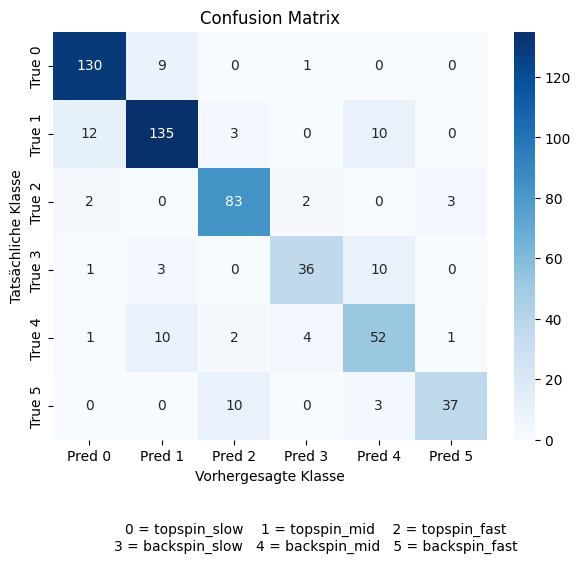

In [15]:
acc = np.sum(np.array(predictions)[:, 0] == np.array(predictions)[:, 1]) / len(predictions)
print(f"Accuracy: {acc*100:.2f}%")

preds = [p for p,l in predictions]
labels = [l for p,l in predictions]

cm = confusion_matrix(labels, preds, labels=list(range(6)))
print("Confusion Matrix:")
print(cm)

# Schöne Visualisierung
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=[f"Pred {i}" for i in range(6)],
            yticklabels=[f"True {i}" for i in range(6)])
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.title("Confusion Matrix")

plt.subplots_adjust(bottom=0.2)  # extra Platz unten

# Beschreibung der Klassen unterhalb einfügen
label_text = (
    "0 = topspin_slow    1 = topspin_mid    2 = topspin_fast\n"
    "3 = backspin_slow   4 = backspin_mid   5 = backspin_fast"
)
plt.figtext(0.5, 0.02, label_text, 
            wrap=True, horizontalalignment='center', fontsize=10)

plt.show()

# Find wrong classified samples

In [16]:
wrong_classified = []
for i, (pred, label) in enumerate(predictions):
    if pred != label:
        wrong_classified.append((i, pred, label))

In [22]:
# find ball-gun settings
outputs = []
path = "/home/lkolmar/Documents/metavision/recordings/new_real_dataset/dataset/full/preprocessed/"
for idx, pred, label in wrong_classified:
    file = [f for f in os.listdir(path + str(idx).zfill(5)) if f.endswith(".txt")][0]
    output = f"idx: {idx}, File: {file}, label {label}, predicted {pred}"
    outputs.append(output)

In [32]:
# get counts of spins and sidespins (all)
spin_counts_full = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 0,
    7: 0,
    -1: 0,
    -2: 0,
    -3: 0,
    -4: 0,
    -5: 0
}
sidespin_counts_full = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    -1: 0,
    -2: 0,
    -3: 0,
    -4: 0,
    -5: 0
}
for idx in range(560):
    file = [f for f in os.listdir(path + str(idx).zfill(5)) if f.endswith(".txt")][0]
    words = file.split("_")
    spin = int(words[0].replace("spin", ""))
    sidespin = int(words[1].replace("sidespin", ""))
    spin_counts_full[spin] += 1
    sidespin_counts_full[sidespin] += 1

In [30]:
spin_counts = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 0,
    7: 0,
    -1: 0,
    -2: 0,
    -3: 0,
    -4: 0,
    -5: 0
}
sidespin_counts = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    -1: 0,
    -2: 0,
    -3: 0,
    -4: 0,
    -5: 0
}
for i in range(len(outputs)):
    idx, pred, label = wrong_classified[i]
    output = outputs[i]
    
    words = output.split(",")[1]
    words = words.replace("File: ", "")
    words = words.split("_")
    spin = int(words[0].replace("spin", ""))
    sidespin = int(words[1].replace("sidespin", ""))
    # print(f"Spin: {spin}, Sidespin: {sidespin} | {output}")
    spin_counts[spin] += 1
    sidespin_counts[sidespin] += 1

    if label in [0,1,2] and pred in [3,4,5] or label in [3,4,5] and pred in [0,1,2]:
        #print(output)
        pass
    else:
        # print(output)
        pass

In [33]:
print("Spin counts for wrong classified samples:")
for k, v in spin_counts.items():
    print(f"Spin {k}: {v} / {spin_counts_full[k]}     {v/spin_counts_full[k]*100 if spin_counts_full[k]>0 else 0:.2f}")
print("Sidespin counts for wrong classified samples:")
for k, v in sidespin_counts.items():
    print(f"Sidespin {k}: {v} / {sidespin_counts_full[k]}     {v/sidespin_counts_full[k]*100 if sidespin_counts_full[k]>0 else 0:.2f}")

Spin counts for wrong classified samples:
Spin 0: 0 / 0     0.00
Spin 1: 0 / 0     0.00
Spin 2: 1 / 30     3.33
Spin 3: 1 / 50     2.00
Spin 4: 8 / 60     13.33
Spin 5: 8 / 70     11.43
Spin 6: 17 / 90     18.89
Spin 7: 7 / 90     7.78
Spin -1: 2 / 10     20.00
Spin -2: 1 / 10     10.00
Spin -3: 19 / 50     38.00
Spin -4: 10 / 50     20.00
Spin -5: 13 / 50     26.00
Sidespin counts for wrong classified samples:
Sidespin 0: 18 / 110     16.36
Sidespin 1: 9 / 90     10.00
Sidespin 2: 14 / 80     17.50
Sidespin 3: 8 / 40     20.00
Sidespin 4: 7 / 20     35.00
Sidespin 5: 0 / 0     0.00
Sidespin -1: 20 / 80     25.00
Sidespin -2: 6 / 80     7.50
Sidespin -3: 5 / 40     12.50
Sidespin -4: 0 / 20     0.00
Sidespin -5: 0 / 0     0.00
